# **Modelo de Harrod-Domar**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

    year           Y         g         s         v    g_pred
0   2000  105.993428       NaN  0.195343  3.006753  6.496800
1   2001  109.723471  3.458621  0.202420  2.857525  7.083739
2   2002  116.295377  5.817000  0.180867  2.945562  6.140330
3   2003  123.046060  5.642545  0.182751  3.011092  6.069253
4   2004  124.531693  1.200149  0.194377  2.884901  6.737741
5   2005  129.531726  3.936559  0.189872  3.037570  6.250776
6   2006  138.158426  6.447520  0.203142  2.939936  6.909758
7   2007  141.534869  2.414508  0.190920  2.970831  6.426477
8   2008  144.061051  1.769106  0.185877  2.939829  6.322713
9   2009  151.085120  4.760621  0.214656  3.185228  6.739125
10  2010  154.073165  1.958420  0.197742  2.998650  6.594375


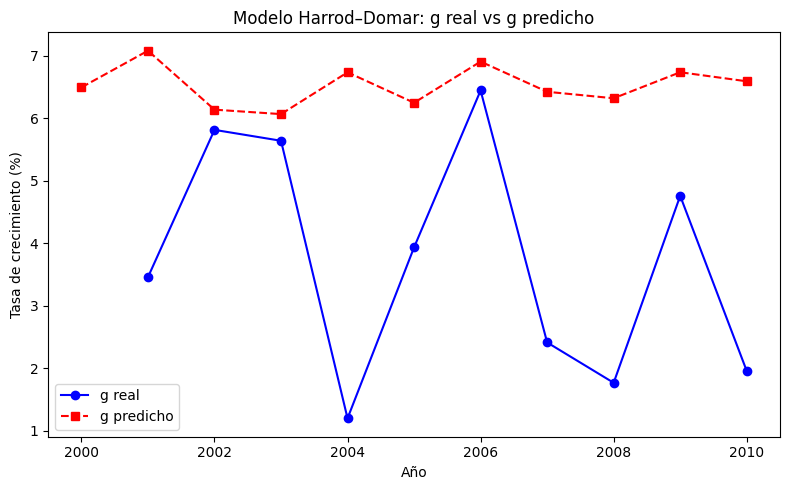

                            OLS Regression Results                            
Dep. Variable:                      g   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.106
Method:                 Least Squares   F-statistic:                    0.1398
Date:                Mon, 11 Aug 2025   Prob (F-statistic):              0.718
Time:                        21:34:53   Log-Likelihood:                -19.870
No. Observations:                  10   AIC:                             43.74
Df Residuals:                       8   BIC:                             44.34
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.4684     12.659      0.669      0.5

In [4]:
# -----------------------
# 1. Generar datos ficticios
# -----------------------
np.random.seed(42)
years = np.arange(2000, 2011)

Y = 100 + 5 * np.arange(1, len(years) + 1) + np.random.normal(0, 2, len(years))
I = Y * (0.20 + np.random.normal(0, 0.01, len(years)))
K = Y * (3.0 + np.random.normal(0, 0.1, len(years)))

df = pd.DataFrame({
    "year": years,
    "Y": Y,
    "I": I,
    "K": K
})

# Guardar en formato Stata
df.to_stata("harrod_domar.dta", write_index=False)

# -----------------------
# 2. Calcular variables
# -----------------------
df["g"] = np.nan
df.loc[1:, "g"] = 100 * (np.log(df["Y"]) - np.log(df["Y"].shift(1)))
df["s"] = df["I"] / df["Y"]
df["v"] = df["K"] / df["Y"]
df["g_pred"] = (df["s"] / df["v"]) * 100

print(df[["year", "Y", "g", "s", "v", "g_pred"]])

# -----------------------
# 3. Gráfico comparativo
# -----------------------
plt.figure(figsize=(8, 5))
plt.plot(df["year"], df["g"], marker='o', label="g real", color="blue")
plt.plot(df["year"], df["g_pred"], marker='s', label="g predicho", color="red", linestyle="--")
plt.title("Modelo Harrod–Domar: g real vs g predicho")
plt.xlabel("Año")
plt.ylabel("Tasa de crecimiento (%)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# -----------------------
# 4. Regresión OLS
# -----------------------
X = df["s"] / df["v"]
y = df["g"]

# Align indices by dropping the first row from both X and y
X = X.iloc[1:]
y = y.iloc[1:]

X = sm.add_constant(X.dropna()) # .dropna() is still needed after .iloc[1:] to handle any potential NaN values later on.
model = sm.OLS(y.dropna(), X).fit() # .dropna() is still needed after .iloc[1:] to handle any potential NaN values later on.
print(model.summary())